# Real-Time Facial Emotion Recognition

EDA, preprocessing, and transfer-learning model comparison (EfficientNetB0, MobileNetV3Large,
ResNet50) for a 7-class facial emotion classifier, feeding into a real-time MediaPipe-based
inference pipeline.

The best-performing backbone is fine-tuned and evaluated once on the held-out test set.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import efficientnet, mobilenet_v3, resnet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100

## 2. Load Dataset

In [ ]:
BASE_PATH = "/content/drive/MyDrive/DATASET"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train")
TEST_IMG_DIR = os.path.join(BASE_PATH, "test")

EMOTION_MAP = {
    1: "Surprise", 2: "Fear", 3: "Disgust", 4: "Happiness",
    5: "Sadness", 6: "Anger", 7: "Neutral",
}
CLASS_NAMES = [EMOTION_MAP[i] for i in range(1, 8)]  # index-aligned with 0-6 labels

train_labels = pd.read_csv(os.path.join(BASE_PATH, "train_labels.csv"))
test_labels = pd.read_csv(os.path.join(BASE_PATH, "test_labels.csv"))

def get_image_path(base_dir, row):
    # images are stored in per-label subfolders: base_dir/<label>/<filename>
    return os.path.join(base_dir, str(row["label"]), row["image"])

print(f"Train samples: {train_labels.shape[0]}")
print(f"Test samples:  {test_labels.shape[0]}")
train_labels.head()

Train samples: 12271
Test samples:  3068


,image,label
0,train_00001_aligned.jpg,5
1,train_00002_aligned.jpg,5
2,train_00003_aligned.jpg,4
3,train_00004_aligned.jpg,4
4,train_00005_aligned.jpg,5


## 3. Dataset Statistics

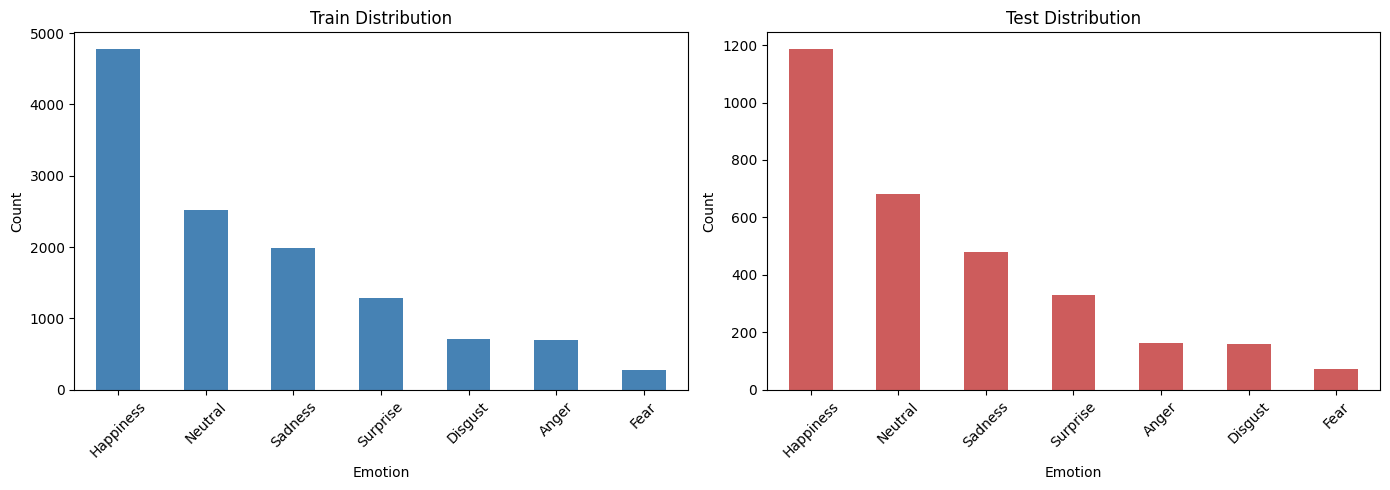

Majority class: Happiness (4772)
Minority class: Fear (281)
Imbalance ratio: 17.0x


In [ ]:
train_labels["emotion"] = train_labels["label"].map(EMOTION_MAP)
test_labels["emotion"] = test_labels["label"].map(EMOTION_MAP)

train_counts = train_labels["emotion"].value_counts()
test_counts = test_labels["emotion"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_counts.plot(kind="bar", ax=axes[0], color="steelblue", title="Train Distribution")
test_counts.plot(kind="bar", ax=axes[1], color="indianred", title="Test Distribution")
for ax in axes:
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Majority class: {train_counts.idxmax()} ({train_counts.max()})")
print(f"Minority class: {train_counts.idxmin()} ({train_counts.min()})")
print(f"Imbalance ratio: {imbalance_ratio:.1f}x")

## 4. Label Verification


In [ ]:
print(train_labels["label"].value_counts().sort_index())
# Reference (official RAF-DB train counts):
# 1 Surprise=1290 | 2 Fear=281 | 3 Disgust=717 | 4 Happiness=4772
# 5 Sadness=1982  | 6 Anger=705 | 7 Neutral=2524

label
1    1290
2     281
3     717
4    4772
5    1982
6     705
7    2524
Name: count, dtype: int64


## 5. Image Validation

In [ ]:
def check_missing(df, img_dir):
    return [p for _, r in df.iterrows() if not os.path.exists(p := get_image_path(img_dir, r))]

def check_corrupted(df, img_dir, sample_size=2000):
    sample = df.sample(min(sample_size, len(df)), random_state=RANDOM_STATE)
    corrupted = []
    for _, row_data in sample.iterrows():
        path = get_image_path(img_dir, row_data)
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            corrupted.append(path)
    return corrupted

missing = len(check_missing(train_labels, TRAIN_IMG_DIR)) + len(check_missing(test_labels, TEST_IMG_DIR))
corrupted = len(check_corrupted(train_labels, TRAIN_IMG_DIR))
duplicates = train_labels["image"].duplicated().sum() + test_labels["image"].duplicated().sum()

print(f"Missing files: {missing}")
print(f"Corrupted (sampled): {corrupted}")
print(f"Duplicate filenames: {duplicates}")

Missing files: 0
Corrupted (sampled): 0
Duplicate filenames: 0


## 6. Image Analysis

In [ ]:
def analyze_images(df, img_dir, sample_size=2000):
    sample = df.sample(min(sample_size, len(df)), random_state=RANDOM_STATE)
    sizes, modes = [], []
    for _, row_data in sample.iterrows():
        with Image.open(get_image_path(img_dir, row_data)) as img:
            sizes.append(img.size)
            modes.append(img.mode)
    return Counter(sizes), Counter(modes)

sizes, modes = analyze_images(train_labels, TRAIN_IMG_DIR)
print("Image sizes:", sizes)
print("Color modes:", modes)  # 'L' = grayscale, 'RGB' = color

Image sizes: Counter({(100, 100): 2000})
Color modes: Counter({'RGB': 2000})


## 7. Sample Visualization

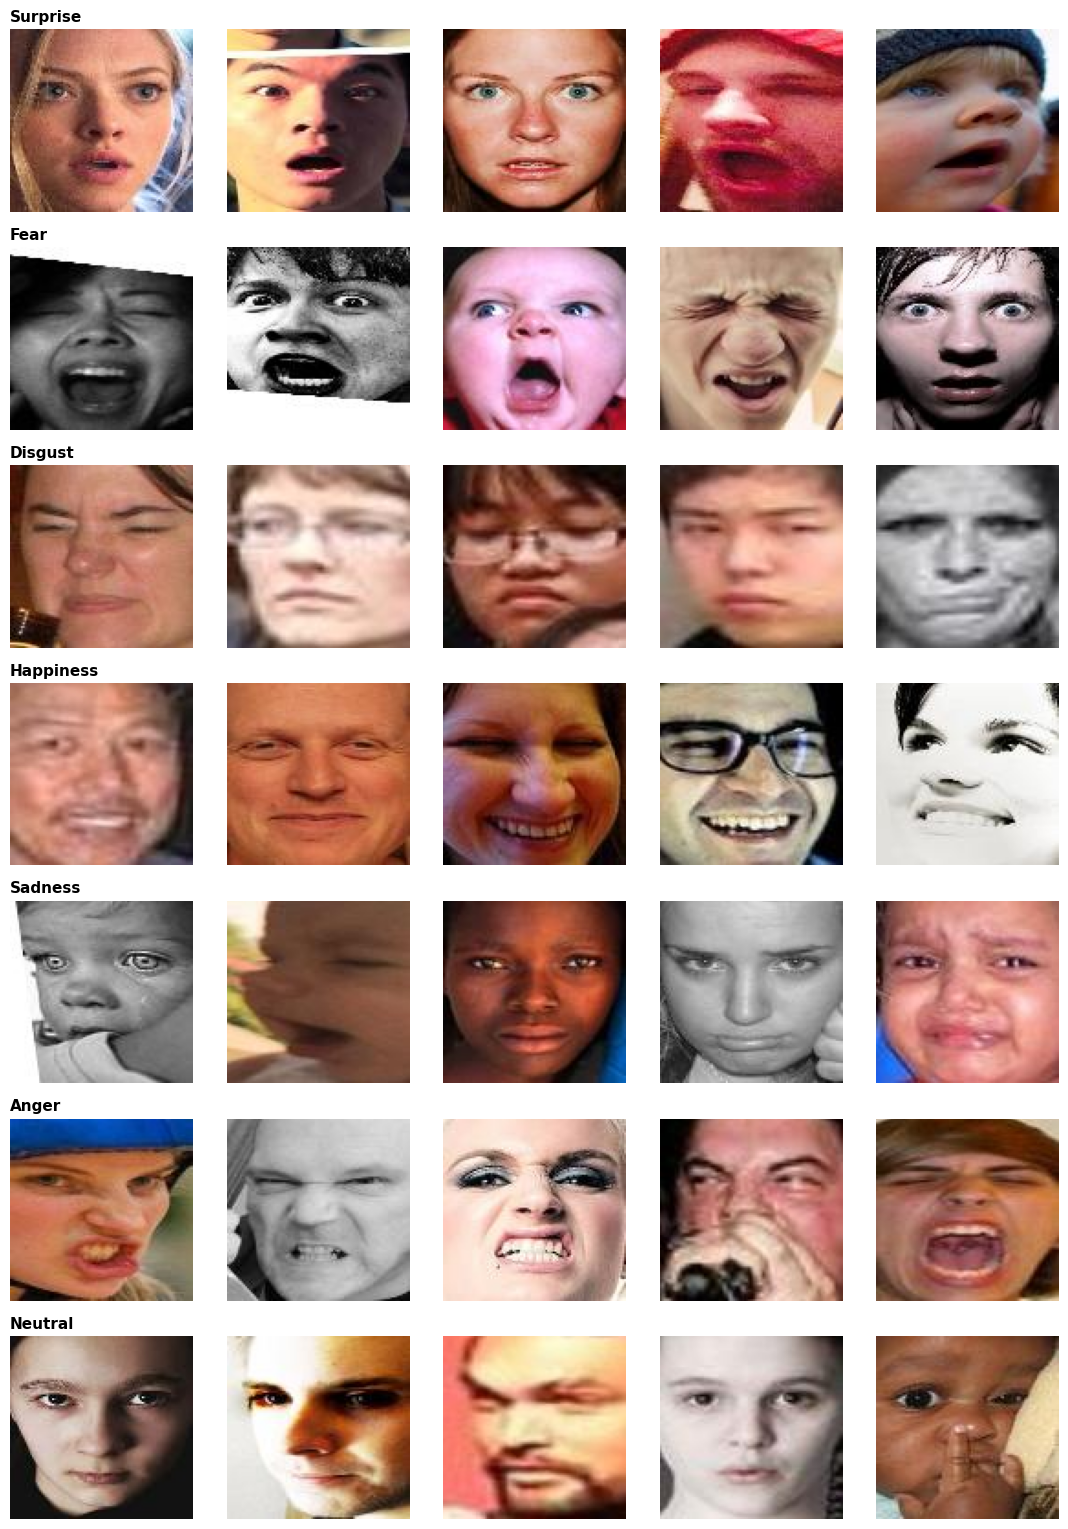

In [ ]:
n_samples = 5
emotions = list(EMOTION_MAP.values())

fig, axes = plt.subplots(len(emotions), n_samples, figsize=(2.2 * n_samples, 2.2 * len(emotions)))

for row_idx, emotion in enumerate(emotions):
    subset = train_labels[train_labels["emotion"] == emotion].sample(n_samples, random_state=RANDOM_STATE)
    for col, (_, row_data) in enumerate(subset.iterrows()):
        img = Image.open(get_image_path(TRAIN_IMG_DIR, row_data))
        ax = axes[row_idx, col]
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.axis("off")
        if col == 0:
            ax.set_title(emotion, loc="left", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Label Encoding & Train/Validation Split



In [ ]:
def encode_labels(label_series):
    return (label_series.values - 1).astype(np.int32)  # 1-7 -> 0-6

train_df, val_df = train_test_split(
    train_labels, test_size=0.15, stratify=train_labels["label"], random_state=RANDOM_STATE,
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_labels)}")

Train: 10430 | Val: 1841 | Test: 3068


## 9. Data Augmentation


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.1),
])
eval_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])


def load_and_preprocess(img_path, transform):
    with Image.open(img_path) as img:
        img_array = np.array(img.convert("RGB"))
    return transform(image=img_array)["image"]

## 10. tf.data Pipeline

In [ ]:
def make_dataset(df, img_dir, transform, batch_size=BATCH_SIZE, shuffle=False):
    paths = [get_image_path(img_dir, row) for _, row in df.iterrows()]
    labels = encode_labels(df["label"])

    def _load(path, label):
        def _py_load(path):
            img = load_and_preprocess(path.numpy().decode("utf-8"), transform)
            return img.astype(np.float32)
        img = tf.py_function(_py_load, [path], tf.float32)
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        label.set_shape([])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=RANDOM_STATE)
    return ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_df, TRAIN_IMG_DIR, train_transform, shuffle=True)
val_ds = make_dataset(val_df, TRAIN_IMG_DIR, eval_transform)
test_ds = make_dataset(test_labels, TEST_IMG_DIR, eval_transform)

## 11. Pipeline Verification

In [ ]:
images, labels = next(iter(train_ds))
print("Batch shape:", images.shape, images.dtype)
print("Value range:", float(tf.reduce_min(images)), "-", float(tf.reduce_max(images)))
print("Label range:", int(tf.reduce_min(labels)), "-", int(tf.reduce_max(labels)))

Batch shape: (32, 224, 224, 3) <dtype: 'float32'>
Value range: 0.0 - 255.0
Label range: 0 - 6


## 12. Training Configuration



In [ ]:
NUM_CLASSES = 7
EPOCHS_HEAD = 15
EPOCHS_FINETUNE = 25
LR_HEAD = 5e-4
LR_FINETUNE = 1e-5
FINE_TUNE_LAYERS = 100
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA = 2.0

MODEL_DIR = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

## 13. Model Builder & Loss Function


In [ ]:
def build_model(backbone_fn, preprocess_fn, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(preprocess_fn, output_shape=input_shape)(inputs)

    backbone = backbone_fn(include_top=False, weights="imagenet", input_tensor=x)
    backbone.trainable = False

    x = layers.GlobalAveragePooling2D()(backbone.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inputs, outputs), backbone


def sparse_categorical_focal_loss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, num_classes=NUM_CLASSES):
    """Focal loss for integer (sparse) labels, with label smoothing folded in."""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes)
        if label_smoothing > 0:
            y_true_oh = y_true_oh * (1.0 - label_smoothing) + label_smoothing / num_classes
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        focal_weight = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

## 14. Resumable Training Helpers



In [ ]:
def get_resume_paths(model_name):
    weights_path = os.path.join(MODEL_DIR, f"{model_name}_latest.weights.h5")
    meta_path = os.path.join(MODEL_DIR, f"{model_name}_epoch.json")
    return weights_path, meta_path


class EpochTracker(callbacks.Callback):
    """Records the last completed epoch after every epoch. `completed` stays False
    until the run finishes normally (see mark_complete) — so an interruption
    mid-training is never mistaken for a finished model."""

    def __init__(self, meta_path):
        super().__init__()
        self.meta_path = meta_path

    def on_epoch_end(self, epoch, logs=None):
        meta = {}
        if os.path.exists(self.meta_path):
            with open(self.meta_path) as f:
                meta = json.load(f)
        meta["last_completed_epoch"] = epoch
        meta["completed"] = False
        with open(self.meta_path, "w") as f:
            json.dump(meta, f)

In [ ]:
def mark_complete(model_name):
    """Called once a training run finishes normally (reached its target epochs or
    stopped early via EarlyStopping). Marks the model as done so a later full-notebook
    restart skips retraining it."""
    weights_path, meta_path = get_resume_paths(model_name)
    meta = {}
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
    meta["completed"] = True
    with open(meta_path, "w") as f:
        json.dump(meta, f)

In [ ]:
def maybe_resume(model, model_name, target_epochs):
    """Returns (initial_epoch, already_done).
    already_done=True means this model previously finished training in full —
    its weights are loaded and the caller should skip calling fit() entirely."""
    weights_path, meta_path = get_resume_paths(model_name)

    if os.path.exists(weights_path) and os.path.exists(meta_path):
        model.load_weights(weights_path)
        with open(meta_path) as f:
            meta = json.load(f)

        if meta.get("completed"):
            print(f"[{model_name}] Already completed training — skipping")
            return target_epochs, True

        resume_epoch = meta["last_completed_epoch"] + 1
        print(f"[{model_name}] Resuming from epoch {resume_epoch}")
        return resume_epoch, False

    print(f"[{model_name}] No checkpoint found — starting fresh")
    return 0, False

In [ ]:
def get_callbacks(model_name):
    weights_path, meta_path = get_resume_paths(model_name)
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, f"{model_name}_best.keras"),
            monitor="val_loss", save_best_only=True,
        ),
        callbacks.ModelCheckpoint(weights_path, save_weights_only=True, save_freq="epoch"),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
        EpochTracker(meta_path),
    ]


def get_finetune_callbacks(model_name):
    """Same idea as get_callbacks, but no ReduceLROnPlateau (the cosine decay schedule
    set on the fine-tune optimizer already handles LR reduction) and a longer
    EarlyStopping patience for the longer 25-epoch run."""
    weights_path, meta_path = get_resume_paths(model_name)
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, f"{model_name}_best.keras"),
            monitor="val_loss", save_best_only=True,
        ),
        callbacks.ModelCheckpoint(weights_path, save_weights_only=True, save_freq="epoch"),
        EpochTracker(meta_path),
    ]

In [ ]:
def cleanup_checkpoint_files(model_name, remove_best_checkpoint=False):
    """Removes only genuinely duplicate artifacts. The resume checkpoint
    (_latest.weights.h5 + _epoch.json) is intentionally NEVER deleted here anymore —
    it's small, and it's what lets a full notebook restart correctly detect an
    already-completed model instead of retraining it."""
    if remove_best_checkpoint:
        best_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")
        if os.path.exists(best_path):
            os.remove(best_path)

## 15. Plotting & Evaluation Helpers

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} — Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def measure_inference_speed(model, dataset, n_batches=5):
    """Average per-image inference time in milliseconds, warmup excluded."""
    batch = next(iter(dataset))[0]
    model.predict(batch, verbose=0)  # warmup

    times = []
    for images, _ in dataset.take(n_batches):
        start = time.perf_counter()
        model.predict(images, verbose=0)
        times.append((time.perf_counter() - start) / images.shape[0])
    return float(np.mean(times) * 1000)


def get_model_size_mb(model_path):
    return os.path.getsize(model_path) / (1024 * 1024)


def save_history_csv(history, model_name):
    """Appends to an existing history file if resuming, so the full multi-session
    history is preserved."""
    path = os.path.join(MODEL_DIR, f"{model_name}_history.csv")
    new_df = pd.DataFrame(history.history)

    if os.path.exists(path):
        existing_df = pd.read_csv(path, index_col="epoch")
        new_df.index = range(len(existing_df), len(existing_df) + len(new_df))
        new_df = pd.concat([existing_df, new_df])

    new_df.to_csv(path, index_label="epoch")
    return path


def evaluate_model(model, dataset, class_names=CLASS_NAMES):
    y_true, y_prob = [], []
    for images, labels_batch in dataset:
        y_prob.append(model.predict(images, verbose=0))
        y_true.append(labels_batch.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = np.argmax(y_prob, axis=1)

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")

    print(classification_report(y_true, y_pred, target_names=class_names))
    print(f"Macro F1: {macro_f1:.4f} | Macro ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": report["accuracy"], "macro_f1": macro_f1, "roc_auc": auc,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
    }

## 16. EfficientNetB0 — Build, Train & Evaluate

In [ ]:
model_effnet, backbone_effnet = build_model(
    tf.keras.applications.EfficientNetB0, efficientnet.preprocess_input,
)
model_effnet.compile(
    optimizer=optimizers.Adam(learning_rate=LR_HEAD),
    loss=sparse_categorical_focal_loss(),
    metrics=["accuracy"],
)

callbacks_effnet = get_callbacks("efficientnet_b0")
initial_epoch_effnet, already_done_effnet = maybe_resume(model_effnet, "efficientnet_b0", EPOCHS_HEAD)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[efficientnet_b0] Already completed training — skipping


In [ ]:
if already_done_effnet:
    print("[efficientnet_b0] Skipping training — already completed.")
    history_effnet = None
else:
    history_effnet = model_effnet.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
        initial_epoch=initial_epoch_effnet,
        callbacks=callbacks_effnet,
    )
    mark_complete("efficientnet_b0")

[efficientnet_b0] Skipping training — already completed.


In [ ]:
if history_effnet is not None:
    plot_history(history_effnet, "EfficientNetB0")
    save_history_csv(history_effnet, "efficientnet_b0")

              precision    recall  f1-score   support

    Surprise       0.73      0.48      0.58       193
        Fear       0.68      0.40      0.51        42
     Disgust       0.43      0.09      0.15       108
   Happiness       0.70      0.86      0.77       716
     Sadness       0.55      0.53      0.54       297
       Anger       0.74      0.37      0.49       106
     Neutral       0.54      0.64      0.59       379

    accuracy                           0.64      1841
   macro avg       0.63      0.48      0.52      1841
weighted avg       0.63      0.64      0.62      1841

Macro F1: 0.5192 | Macro ROC-AUC: 0.8748


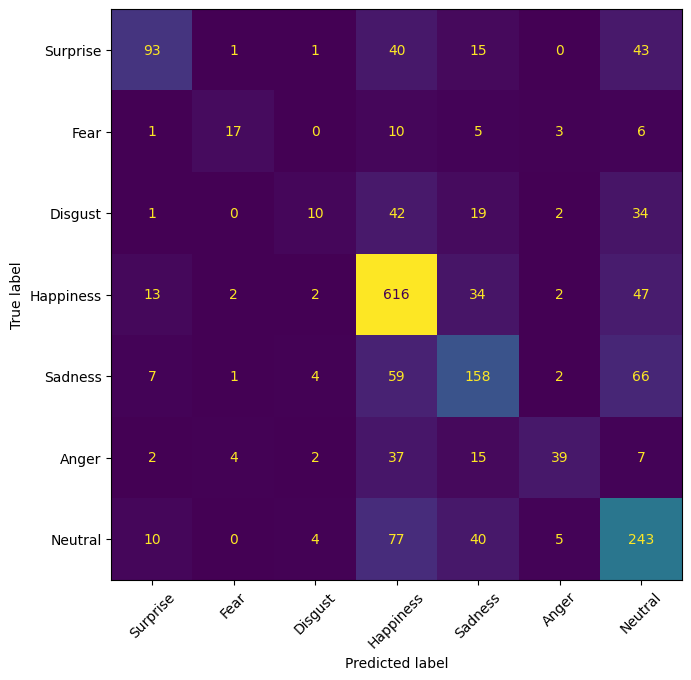

In [ ]:
metrics_effnet = evaluate_model(model_effnet, val_ds)
metrics_effnet["inference_ms"] = measure_inference_speed(model_effnet, val_ds)

effnet_path = os.path.join(MODEL_DIR, "efficientnet_b0_best.keras")
metrics_effnet["size_mb"] = get_model_size_mb(effnet_path)
metrics_effnet["path"] = effnet_path

## 17. MobileNetV3Large — Build, Train & Evaluate

In [ ]:
model_mobilenet, backbone_mobilenet = build_model(
    tf.keras.applications.MobileNetV3Large, mobilenet_v3.preprocess_input,
)
model_mobilenet.compile(
    optimizer=optimizers.Adam(learning_rate=LR_HEAD),
    loss=sparse_categorical_focal_loss(),
    metrics=["accuracy"],
)

callbacks_mobilenet = get_callbacks("mobilenet_v3_large")
initial_epoch_mobilenet, already_done_mobilenet = maybe_resume(model_mobilenet, "mobilenet_v3_large", EPOCHS_HEAD)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[mobilenet_v3_large] Already completed training — skipping


In [ ]:
if already_done_mobilenet:
    print("[mobilenet_v3_large] Skipping training — already completed.")
    history_mobilenet = None
else:
    history_mobilenet = model_mobilenet.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
        initial_epoch=initial_epoch_mobilenet,
        callbacks=callbacks_mobilenet,
    )
    mark_complete("mobilenet_v3_large")

[mobilenet_v3_large] Skipping training — already completed.


In [ ]:
if history_mobilenet is not None:
    plot_history(history_mobilenet, "MobileNetV3Large")
    save_history_csv(history_mobilenet, "mobilenet_v3_large")

              precision    recall  f1-score   support

    Surprise       0.71      0.44      0.54       193
        Fear       0.75      0.29      0.41        42
     Disgust       0.33      0.06      0.11       108
   Happiness       0.64      0.85      0.73       716
     Sadness       0.50      0.48      0.49       297
       Anger       0.57      0.36      0.44       106
     Neutral       0.56      0.59      0.58       379

    accuracy                           0.60      1841
   macro avg       0.58      0.44      0.47      1841
weighted avg       0.59      0.60      0.58      1841

Macro F1: 0.4711 | Macro ROC-AUC: 0.8484


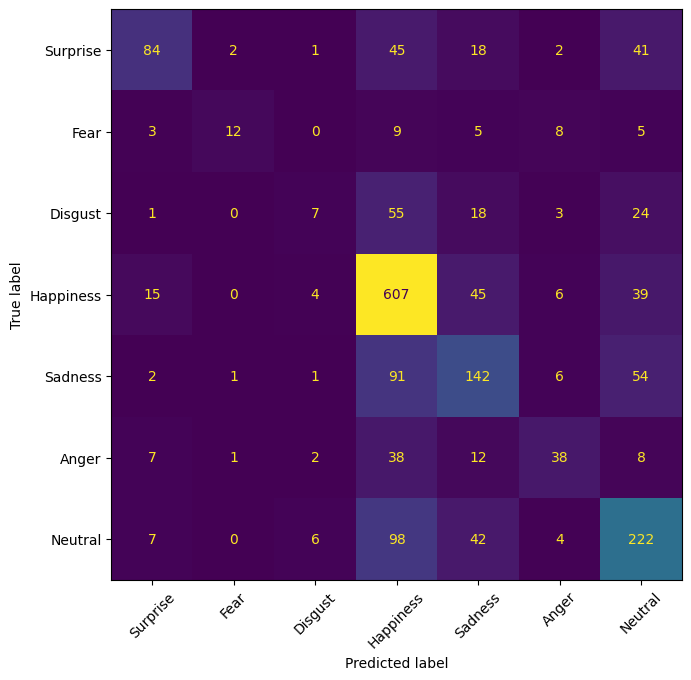

In [ ]:
metrics_mobilenet = evaluate_model(model_mobilenet, val_ds)
metrics_mobilenet["inference_ms"] = measure_inference_speed(model_mobilenet, val_ds)

mobilenet_path = os.path.join(MODEL_DIR, "mobilenet_v3_large_best.keras")
metrics_mobilenet["size_mb"] = get_model_size_mb(mobilenet_path)
metrics_mobilenet["path"] = mobilenet_path

## 18. ResNet50 — Build, Train & Evaluate

In [ ]:
model_resnet, backbone_resnet = build_model(
    tf.keras.applications.ResNet50, resnet50.preprocess_input,
)
model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=LR_HEAD),
    loss=sparse_categorical_focal_loss(),
    metrics=["accuracy"],
)

callbacks_resnet = get_callbacks("resnet50")
initial_epoch_resnet, already_done_resnet = maybe_resume(model_resnet, "resnet50", EPOCHS_HEAD)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[resnet50] Already completed training — skipping


In [ ]:
if already_done_resnet:
    print("[resnet50] Skipping training — already completed.")
    history_resnet = None
else:
    history_resnet = model_resnet.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
        initial_epoch=initial_epoch_resnet,
        callbacks=callbacks_resnet,
    )
    mark_complete("resnet50")

[resnet50] Skipping training — already completed.


In [ ]:
if history_resnet is not None:
    plot_history(history_resnet, "ResNet50")
    save_history_csv(history_resnet, "resnet50")

              precision    recall  f1-score   support

    Surprise       0.69      0.51      0.59       193
        Fear       0.70      0.38      0.49        42
     Disgust       0.39      0.10      0.16       108
   Happiness       0.74      0.86      0.79       716
     Sadness       0.60      0.54      0.57       297
       Anger       0.65      0.37      0.47       106
     Neutral       0.54      0.71      0.62       379

    accuracy                           0.66      1841
   macro avg       0.62      0.50      0.53      1841
weighted avg       0.65      0.66      0.64      1841

Macro F1: 0.5275 | Macro ROC-AUC: 0.8910


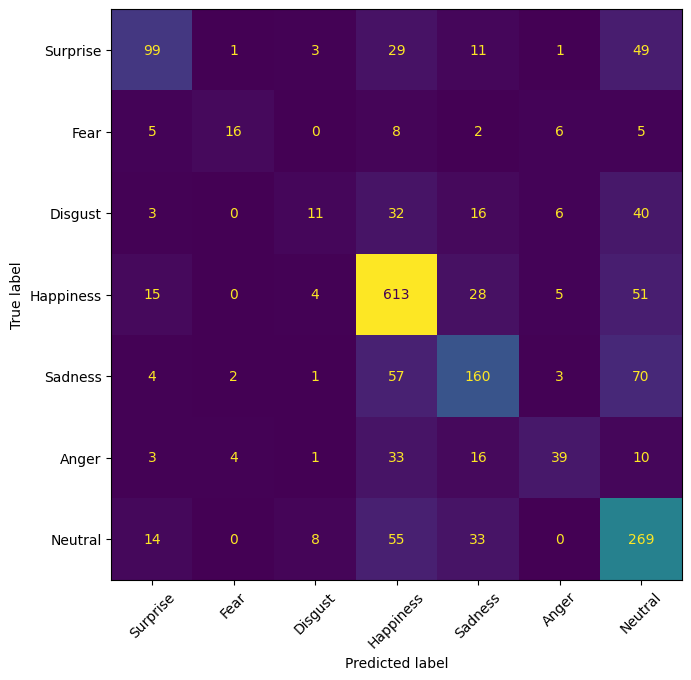

In [ ]:
metrics_resnet = evaluate_model(model_resnet, val_ds)
metrics_resnet["inference_ms"] = measure_inference_speed(model_resnet, val_ds)

resnet_path = os.path.join(MODEL_DIR, "resnet50_best.keras")
metrics_resnet["size_mb"] = get_model_size_mb(resnet_path)
metrics_resnet["path"] = resnet_path

## 19. Compare All Models

In [ ]:
# All metrics below are computed on the validation set. The test set stays
# untouched until Section 22, after the best model is selected and fine-tuned.
results = {
    "EfficientNetB0": metrics_effnet,
    "MobileNetV3Large": metrics_mobilenet,
    "ResNet50": metrics_resnet,
}

comparison_df = pd.DataFrame({
    name: {
        "Val Accuracy": m["accuracy"],
        "Val Macro F1": m["macro_f1"],
        "Val ROC-AUC": m["roc_auc"],
        "Inference (ms/img)": m["inference_ms"],
        "Size (MB)": m["size_mb"],
    }
    for name, m in results.items()
}).T

comparison_df

,Val Accuracy,Val Macro F1,Val ROC-AUC,Inference (ms/img),Size (MB)
EfficientNetB0,0.638783,0.519216,0.874809,91.532470,20.091292
MobileNetV3Large,0.604020,0.471069,0.848443,59.895927,14.975340
ResNet50,0.655622,0.527492,0.890966,299.557093,96.719176


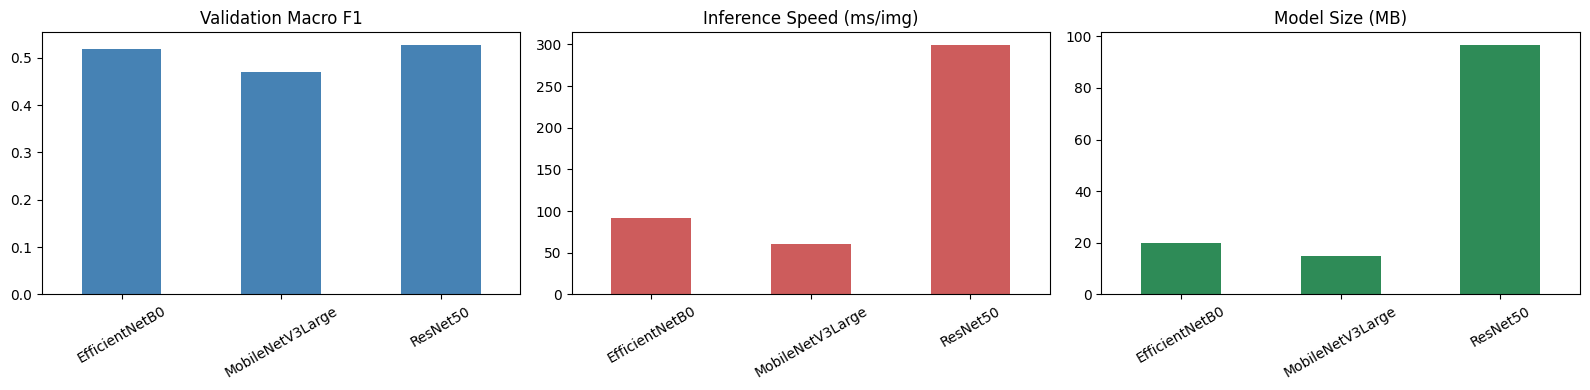

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
comparison_df["Val Macro F1"].plot(kind="bar", ax=axes[0], color="steelblue", title="Validation Macro F1")
comparison_df["Inference (ms/img)"].plot(kind="bar", ax=axes[1], color="indianred", title="Inference Speed (ms/img)")
comparison_df["Size (MB)"].plot(kind="bar", ax=axes[2], color="seagreen", title="Model Size (MB)")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 20. Select Best Model


In [ ]:
best_name = comparison_df["Val Macro F1"].idxmax()
best_model_map = {
    "EfficientNetB0": (model_effnet, backbone_effnet, "efficientnet_b0"),
    "MobileNetV3Large": (model_mobilenet, backbone_mobilenet, "mobilenet_v3_large"),
    "ResNet50": (model_resnet, backbone_resnet, "resnet50"),
}
best_model, best_backbone, best_name_slug = best_model_map[best_name]

print(f"Selected backbone: {best_name}")
print(comparison_df.loc[best_name])

Selected backbone: ResNet50
Val Accuracy            0.655622
Val Macro F1            0.527492
Val ROC-AUC             0.890966
Inference (ms/img)    299.557093
Size (MB)              96.719176
Name: ResNet50, dtype: float64


## 21. Fine-Tune Best Model

In [ ]:
best_backbone.trainable = True
for layer in best_backbone.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
finetune_lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FINETUNE,
    decay_steps=steps_per_epoch * EPOCHS_FINETUNE,
    alpha=0.05,
)

best_model.compile(
    optimizer=optimizers.Adam(learning_rate=finetune_lr_schedule),
    loss=sparse_categorical_focal_loss(),
    metrics=["accuracy"],
)

finetune_name = f"{best_name_slug}_finetuned"
finetune_callbacks = get_finetune_callbacks(finetune_name)
initial_epoch_finetune, already_done_finetune = maybe_resume(best_model, finetune_name, EPOCHS_FINETUNE)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 261 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[resnet50_finetuned] Already completed training — skipping


In [ ]:
if already_done_finetune:
    print(f"[{finetune_name}] Skipping training — already completed.")
    history_finetune = None
else:
    history_finetune = best_model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
        initial_epoch=initial_epoch_finetune,
        callbacks=finetune_callbacks,
    )
    mark_complete(finetune_name)

if history_finetune is not None:
    plot_history(history_finetune, f"{best_name} — Fine-Tuned")
    save_history_csv(history_finetune, finetune_name)

[resnet50_finetuned] Skipping training — already completed.


## 22. Final Test Evaluation

First and only evaluation on the held-out test set — untouched until now.

              precision    recall  f1-score   support

    Surprise       0.85      0.78      0.81       329
        Fear       0.68      0.49      0.57        74
     Disgust       0.61      0.39      0.47       160
   Happiness       0.86      0.94      0.90      1185
     Sadness       0.76      0.74      0.75       478
       Anger       0.74      0.62      0.68       162
     Neutral       0.75      0.77      0.76       680

    accuracy                           0.80      3068
   macro avg       0.75      0.68      0.71      3068
weighted avg       0.79      0.80      0.79      3068

Macro F1: 0.7051 | Macro ROC-AUC: 0.9410


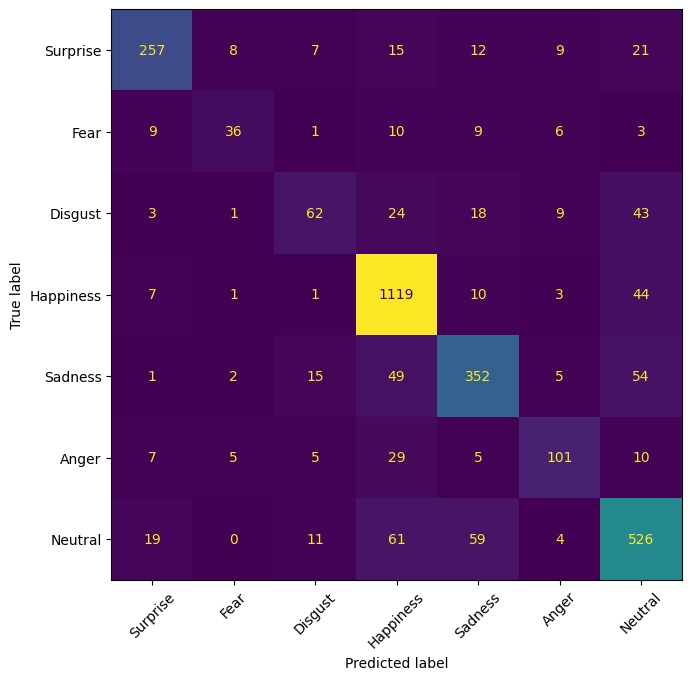

Final test accuracy: 0.7995
Final test macro F1: 0.7051


In [ ]:
final_metrics = evaluate_model(best_model, test_ds)
final_metrics["inference_ms"] = measure_inference_speed(best_model, test_ds)

print(f"Final test accuracy: {final_metrics['accuracy']:.4f}")
print(f"Final test macro F1: {final_metrics['macro_f1']:.4f}")

## 23. Save Final Model


In [ ]:
final_path = os.path.join(MODEL_DIR, "final_model.keras")
best_model.save(final_path)
cleanup_checkpoint_files(finetune_name, remove_best_checkpoint=True)

with open(os.path.join(MODEL_DIR, "training_summary.json"), "w") as f:
    json.dump({
        "comparison": comparison_df.to_dict(orient="index"),
        "selected_model": best_name,
        "final_test_accuracy": final_metrics["accuracy"],
        "final_test_macro_f1": final_metrics["macro_f1"],
        "final_test_roc_auc": final_metrics["roc_auc"],
        "final_model_path": final_path,
    }, f, indent=2)

print(f"Saved final model to {final_path}")

Saved final model to /content/drive/MyDrive/DATASET/models/final_model.keras
